# Recherche Opérationnelle

## Introduction

Face aux défis climatiques actuels, la transition écologique impose de repenser en profondeur nos modes de fonctionnement industriels et logistiques. C'est dans cette dynamique que l'ADEME (Agence de l'Environnement et de la Maîtrise de l'Énergie) a lancé un appel à manifestation d'intérêt visant à promouvoir le développement de nouvelles solutions de mobilité intelligente. 

Le laboratoire **CesiCDP**, fort de son expertise en logistique multimodale, se positionne sur cet appel à projets avec un objectif clair : concevoir un outil algorithmique capable d'optimiser les tournées de livraison de marchandises. En minimisant les distances parcourues et en maximisant l'efficacité des flottes de véhicules, ce projet ambitionne de réduire significativement l'empreinte carbone et les coûts opérationnels liés au transport.

Ce document constitue le premier livrable de notre étude. Il a pour but de poser les fondations théoriques de notre solution en formalisant le problème logistique rencontré, en définissant les contraintes de terrain, et en démontrant la complexité mathématique inhérente à sa résolution.


## Chapitre 1 - Modélisation

### Présentation du problème et de son contexte

#### Contexte

Dans le cadre de l'appel à manifestation d'intérêt lancé par l'ADEME, le laboratoire CesiCDP se positionne pour concevoir de nouvelles solutions de mobilité multimodale intelligente. Face aux défis climatiques et à l'augmentation des flux de marchandises, l'enjeu est d'optimiser la logistique du transport (distribution, livraison, ramassage).

L'objectif environnemental est direct : limiter les déplacements inutiles et optimiser la gestion des ressources pour réduire drastiquement la consommation de carburant et les émissions polluantes.

#### Problématique

Le défi algorithmique central consiste à calculer une tournée sur un réseau routier permettant de relier un sous-ensemble défini de villes, puis de revenir au point de départ.

L’objectif est de minimiser la distance totale ou la durée globale des trajets effectués par une flotte de véhicules pour desservir un ensemble de clients. Bien que ce défi relève du Problème de **Tournées de Véhicules (VRP)**, un enjeu central de la logistique moderne, la réalité du terrain impose des défis supplémentaires.

#### Contraintes Choisies

Pour garantir un démonstrateur réaliste et applicable à l'industrie, nous intégrons les contraintes suivantes, transformant le problème en un Problème de Tournées de Véhicules avec Capacités (CVRP) :
1. **Utilisation de plusieurs véhicules :** Il peut y avoir plusieurs sous-tournées plutôt qu'une seule grande tournée.
2. **Capacité des véhicules :** Si la contrainte précédente a été choisie, chaque véhicule a une capacité limite pour transporter des marchandises ou des passagers.



### Représentation formelle

Pour traiter ce problème algorithmiquement, nous le traduisons mathématiquement à l'aide de la théorie des graphes.

#### Les données (Le réseau)

Le réseau routier est modélisé par un graphe complet orienté et pondéré $G = (V, E)$.
- **Sommets :** $V = \{v_0, v_1, \dots, v_n\}$ où $v_0$ représente le dépôt central (départ/arrivée) et $V \setminus \{v_0\}$ l'ensemble des villes à livrer.
- **Arêtes :** $E$ représente l'ensemble des routes reliant les villes.
- **Coûts :** Chaque arête $(v_i, v_j)$ a un poids $c_{ij}$ (distance ou temps de trajet).
- **Demandes :** Chaque ville $v_i$ nécessite la livraison d'une quantité de marchandises $q_i$. La demande du dépôt est $q_0 = 0$.
- **Véhicules :** Une flotte de $K$ véhicules, ayant chacun une capacité maximale $Q$.


#### Étude et Démonstration de la Complexité Théorique

L'étude des propriétés théoriques de notre modèle (le CVRP) révèle qu'il s'agit d'un problème combinatoire complexe combinant deux dimensions difficiles : l'ordre de visite (Parcours) et la répartition des charges dans une flotte limitée (Bin Packing).

#### Version décisionnelle

Pour évaluer la complexité, nous définissons le problème de décision associé : \\
*Existe-t-il un ensemble de tournées valides (commençant au dépôt, visitant chaque ville une fois sans dépasser la capacité $Q$) dont le coût total est $\leq L$ ?*

#### Appartenance à la classe NP

Un problème est dans la classe NP si la validité d'une solution candidate (certificat) peut être vérifiée en temps polynomial par rapport à la taille de l'entrée $n$. 

Pour un ensemble de parcours donné, nous pouvons :
- Vérifier que chaque ville est visitée exactement une fois (Temps $\mathcal{O}(n)$).
- Sommer les demandes $q_i$ par véhicule pour vérifier que le total est $\leq Q$ (Temps $\mathcal{O}(n)$).
- Additionner les coûts $c_{ij}$ pour vérifier que la somme est $\leq L$ (Temps $\mathcal{O}(n)$).


Algorithme de vérification de solution:
```
Variables:
    Liste sommetsVisites
    Réel tempsTotal <- 0
    Entier n <- taille(solution)

Début:
    # 1. Vérification de la complétude
    Si n != G.nombreSommets():
        Renvoyer Faux
    Fin Si

    Pour i allant de 0 à n - 1:
        Sommet actuel <- solution[i]

        # 2. Vérifier si le sommet existe dans le graphe et n'est pas un doublon
        Si NON G.existeSommet(actuel) OU actuel appartient à sommetsVisites:
            Renvoyer Faux
        Fin Si
        sommetsVisites.ajouter(actuel)

        # 3. Calcul du temps et continuité du chemin
        Sommet suivant <- solution[i + 1]
        Arrete arc <- G.trouverArrete(actuel, suivant)

        Si estVide(arc):
            Renvoyer Faux
        Sinon:
            tempsTotal <- tempsTotal + arc.poids
        Fin Si
    Fin Pour

    # 4. Vérification de la contrainte de temps
    Si tempsTotal > tempsMax:
        Renvoyer Faux
    Fin Si

    Renvoyer Vrai
Fin
```

Les vérifications s'effectuant en temps polynomial, le problème appartient bien à NP.

#### Démonstration de la NP-difficulté (par restriction)

Pour prouver formellement la NP-difficulté, nous démontrons par restriction que notre problème contient un cas particulier déjà connu comme NP-difficile : le Problème du Voyageur de Commerce (TSP).

- **Problème source :** Le TSP est prouvé NP-difficile.
- **Réduction :** Fixons les paramètres de notre problème avec $K = 1$ véhicule, et une capacité $Q$ suffisamment grande pour couvrir la somme de toutes les demandes ($\sum q_i \leq Q$).
- **Équivalence :** Dans ce cas de figure, la contrainte de capacité $Q$ disparaît de fait. Le problème se réduit exactement à trouver le cycle hamiltonien de coût minimal traversant toutes les villes, ce qui est la définition stricte du TSP.
- **Conclusion :** Puisque notre modèle peut se réduire au TSP, il est au moins aussi difficile à résoudre. Il est donc NP-difficile.

#### Conclusion sur la complexité

Étant simultanément dans NP et NP-difficile, notre problème d'optimisation de tournées avec capacités est **s**. Il est donc hautement improbable qu'un algorithme exact puisse le résoudre en temps polynomial pour de grandes instances de réseaux routiers, justifiant l'utilisation future de méthodes heuristiques ou méta-heuristiques.



# 0 - préparation
installation et importacion des libréries nécessaires


In [ ]:
import math
from math import trunc
%pip install matplotlib pulp ipywidgets IPython numpy

In [1]:
import random
import time
import matplotlib.pyplot as plt
from collections import deque
from pulp import *
from ipywidgets import IntProgress
from IPython.display import display
import statistics
import numpy as np

# 1 - représentation du problème
La solution serat représenté par un liste avec la liste du chemin de chaque véhicule.

## 2.1 modélisation
#### fonction objectif
$$\text{Min } Z = \sum_{k=1}^{K} \sum_{i=0}^{n} \sum_{j=0}^{n} c_{ij} x_{ijk}$$
#### sous contraintes:
1. Unicité de visite :
$$\sum_{k=1}^{K} \sum_{i=1}^{n} x_{ijk} = 1 \quad \forall j \in \{1, \dots, n\}$$

2. Conservation du flux (Retour au dépôt) :
$$\sum_{i=0}^{n} x_{i0k} - \sum_{j=0}^{n} x_{0jk} = 0 \quad \forall k \in \{1, \dots, K\}$$

3. sous tour:
$$u_{jk} \geq u_{ik} + q_j - Q_{max}(1 - x_{ijk}) \quad \forall i, j \in \{1, \dots, n\}, i \neq j, \forall k$$

4. Capacité des véhicules :
$$ \sum_{i=0}^{n}\sum_{j=0}^{n} q_i \cdot x_{jik} \leq Q_{max} \quad \forall k \in \{1, \dots, K\}$$

5. Activation des véhicules :
$$\sum_{j=1}^{n} x_{0jk} \leq 1 \quad \forall k \in \{1, \dots, K\}$$

## 1.2 génerer des instances aléatoires

In [ ]:
def generer_instance(n = None,nb_vehicules = None , n_max = 15,nb_vehicules_max = 10, max_capacite_coeff = 2.5):

    ## faire random?
    n = random.randint(5,n_max) if n is None else int(n)
    nb_vehicules = random.randint(2,nb_vehicules_max) if nb_vehicules is None else int(nb_vehicules)



    taille = n + 1
    matrice = [[0] * taille for _ in range(taille)]

    for i in range(taille):
        for j in range(i + 1, taille):
            dist = random.randint(5,50) if random.random() > 0.1 else float('inf')
            matrice[i][j] = dist
            matrice[j][i] = dist

    demandes = [0]
    total_colis = 0
    for _ in range(n):
        d = random.randint(1, 10)
        demandes.append(d)
        total_colis += d
    capacite_min = math.ceil(total_colis / nb_vehicules)
    capacite_max = int(capacite_min * random.uniform(1.1, max_capacite_coeff))

    print(f"\n--- Instance générée ---")
    print(f"Total colis à livrer : {total_colis}")
    print(f"Capacité par véhicule : {capacite_max}")

    return n, nb_vehicules, matrice, demandes, capacite_max

def distance_total(solution, matrice):
    """ Calcule la fonction objectif Z (Somme des distances) """
    z = 0
    for tournee in solution:
        for i in range(len(tournee) - 1):
            z += matrice[tournee[i]][tournee[i+1]]
    return z




def generer_random_solution(n, nb_vehicules, demandes, capacite_max):
    villes = list(range(1, n + 1))
    random.shuffle(villes)  # Mélange aléatoire des villes

    solution = []
    tournee_actuelle = [0] # On part du dépôt
    charge_actuelle = 0

    for ville in villes:
        demande_ville = demandes[ville]

        # Si on peut ajouter la ville dans le véhicule actuel
        if charge_actuelle + demande_ville <= capacite_max:
            tournee_actuelle.append(ville)
            charge_actuelle += demande_ville
        else:
            # Le véhicule est plein, on ferme la tournée et on rentre au dépôt
            tournee_actuelle.append(0)
            solution.append(tournee_actuelle)

            # On commence une nouvelle tournée avec la ville actuelle
            tournee_actuelle = [0, ville]
            charge_actuelle = demande_ville

    # Ne pas oublier de fermer la dernière tournée
    tournee_actuelle.append(0)
    solution.append(tournee_actuelle)

    # --- Gestion du nombre de véhicules ---
    # Si on a utilisé plus de véhicules que prévu
    if len(solution) > nb_vehicules:
        print(f"Attention : L'instance nécessite {len(solution)} véhicules, mais seulement {nb_vehicules} sont autorisés.")
        return None

    # Si on en a utilisé moins, on peut ajouter des tournées vides [0, 0]
    while len(solution) < nb_vehicules:
        solution.append([0, 0])

    return solution

def afficher_resultats(titre, solution, matrice, demandes, capacite_max):
    distance = distance_total(solution, matrice, demandes, capacite_max)
    print(f"\n{'='*15} {titre} {'='*15}")
    print(f"DISTANCE TOTALE : {distance}")
    print(f"VECTEUR SOLUTION : {solution}")
    print("-" * (32 + len(titre)))

    numero_camion = 1
    route_actuelle = []
    charge_camion = 0

    for i in range(len(solution)):
        ville = solution[i]

        if ville == 0:
            if len(route_actuelle) > 0:
                print(f"Camion {numero_camion} [Charge {charge_camion}/{capacite_max}] : 0 -> {' -> '.join(map(str, route_actuelle))} -> 0")
                numero_camion += 1
                route_actuelle = []
                charge_camion = 0
        else:
            route_actuelle.append(ville)
            charge_camion += demandes[ville]

    if len(route_actuelle) > 0:
        print(f"Camion {numero_camion} [Charge {charge_camion}/{capacite_max}] : 0 -> {' -> '.join(map(str, route_actuelle))} -> 0")


## 1.3 verifier la solutions

In [ ]:
def verifier_solution(solution, matrice, demandes, capacite_max):
    """
    Vérifie si une solution (liste de listes) respecte toutes les contraintes.
    """
    n = len(matrice)
    villes_visitees = []

    for k, tournee in enumerate(solution):
        # --- Contrainte 5 : Activation du véhicule ---
        # On vérifie si le véhicule part du dépôt (sommet 0)
        if len(tournee) <= 2: # Une tournée vide ou juste [0,0]
            continue

        # --- Contrainte 2 : Conservation du flux (Départ et Retour Dépôt) ---
        if tournee[0] != 0 or tournee[-1] != 0:
            print(f"Erreur Véhicule {k} : Doit commencer et finir au dépôt (0).")
            return False

        charge_vehicule = 0
        for i in range(len(tournee) - 1):
            u = tournee[i]
            v = tournee[i+1]

            # --- Vérification de l'existence du trajet (Graphe) ---
            if matrice[u][v] == float('inf'):
                print(f"Erreur : Trajet impossible entre {u} et {v}.")
                return False

            # On suit les villes visitées (hors dépôt) pour l'unicité
            if v != 0:
                villes_visitees.append(v)
                charge_vehicule += demandes[v]

        # --- Contrainte 4 : Capacité des véhicules ---
        if charge_vehicule > capacite_max:
            print(f"Erreur Véhicule {k} : Capacité dépassée ({charge_vehicule} > {capacite_max}).")
            return False

    # --- Contrainte 1 : Unicité de visite ---
    # On vérifie si chaque ville {1..n} apparaît exactement une fois
    if sorted(villes_visitees) != list(range(1, n + 1)):
        print(f"Erreur : Les villes visitées {sorted(villes_visitees)} ne correspondent pas à la liste attendue.")
        return False

    return True



# 2 - résolutions

## 2.2 Résolution Algo tabu

## 2.3 résolution algo génétique

## 2.4 résolution aglo marine

# 2.4 Résolution par Colonies de Fourmis (Ant Colony Optimization)

Ce notebook implémente un troisième algorithme pour le CVRP : **Ant Colony Optimization (ACO)**.

## Principe

ACO est une métaheuristique inspirée du comportement des fourmis réelles : elles déposent des phéromones sur leurs chemins, et les pistes courtes voient leurs phéromones s'accumuler plus vite, créant une convergence collective vers les meilleurs trajets.

Pour le CVRP, chaque *fourmi artificielle* construit une solution complète (un ensemble de tournées) de la manière suivante :

1. Partir du dépôt avec un véhicule vide.
2. Choisir la prochaine ville non visitée selon la règle probabiliste :
$$P(i \to j) = \frac{[\tau_{ij}]^{\alpha} \cdot [\eta_{ij}]^{\beta}}{\sum_{l \in \text{faisable}} [\tau_{il}]^{\alpha} \cdot [\eta_{il}]^{\beta}}$$
   où $\tau_{ij}$ est le niveau de phéromone et $\eta_{ij} = 1/c_{ij}$ est l'information heuristique (inverse de la distance).
3. Si aucune ville ne rentre dans la capacité restante, retour au dépôt et ouverture d'un nouveau véhicule.
4. Continuer jusqu'à avoir visité toutes les villes.

À chaque itération, les phéromones s'évaporent ($\tau \leftarrow (1-\rho)\tau$) puis les fourmis déposent une quantité proportionnelle à la qualité de leur solution ($\Delta\tau = Q/L$, où $L$ est la distance totale).

## Paramètres
- $\alpha$ : poids des phéromones (exploitation du savoir accumulé)
- $\beta$ : poids de l'heuristique (attirance des villes proches)
- $\rho$ : taux d'évaporation (entre 0 et 1)
- $Q$ : constante de dépôt
- `n_fourmis` : nombre de fourmis par itération
- `n_iter` : nombre d'itérations

## Préparation — imports et génération d'instance

Reprise des mêmes conventions que `ProjetFinal.ipynb` : solution = liste de tournées, chaque tournée commence et finit au dépôt (sommet 0).

In [ ]:
import math
import random
import time
import statistics
import numpy as np
import matplotlib.pyplot as plt
from collections import deque

In [ ]:
def generer_instance(n=None, nb_vehicules=None, n_max=15, nb_vehicules_max=10, max_capacite_coeff=2.5):
    n = random.randint(5, n_max) if n is None else int(n)
    nb_vehicules = random.randint(2, nb_vehicules_max) if nb_vehicules is None else int(nb_vehicules)
    taille = n + 1
    matrice = [[0] * taille for _ in range(taille)]
    for i in range(taille):
        for j in range(i + 1, taille):
            dist = random.randint(5, 50) if random.random() > 0.1 else float('inf')
            matrice[i][j] = dist
            matrice[j][i] = dist
    demandes = [0]
    total_colis = 0
    for _ in range(n):
        d = random.randint(1, 10)
        demandes.append(d)
        total_colis += d
    capacite_min = math.ceil(total_colis / nb_vehicules)
    capacite_max = int(capacite_min * random.uniform(1.1, max_capacite_coeff))
    print(f"\n--- Instance générée ---")
    print(f"Total colis à livrer : {total_colis}")
    print(f"Capacité par véhicule : {capacite_max}")
    return n, nb_vehicules, matrice, demandes, capacite_max

def distance_total(solution, matrice):
    z = 0
    for tournee in solution:
        for i in range(len(tournee) - 1):
            z += matrice[tournee[i]][tournee[i+1]]
    return z

def verifier_solution(solution, matrice, demandes, capacite_max):
    n = len(matrice)
    villes_visitees = []
    for k, tournee in enumerate(solution):
        if len(tournee) <= 2:
            continue
        if tournee[0] != 0 or tournee[-1] != 0:
            return False
        charge = 0
        for i in range(len(tournee) - 1):
            u, v = tournee[i], tournee[i+1]
            if matrice[u][v] == float('inf'):
                return False
            if v != 0:
                villes_visitees.append(v)
                charge += demandes[v]
        if charge > capacite_max:
            return False
    return sorted(villes_visitees) == list(range(1, n))


## Implémentation d'ACO

### Construction d'une solution par une fourmi

Une fourmi construit une solution en enchaînant des tournées. Pour chaque ville à visiter, elle calcule la probabilité de chaque ville candidate (non visitée, rentrant dans la capacité restante, accessible) et tire au sort.

In [ ]:
def _construire_solution_fourmi(matrice, demandes, capacite_max, nb_vehicules, pheromones, alpha, beta):
    """Une fourmi construit une solution complète (liste de tournées)."""
    n = len(matrice) - 1  # nombre de villes (hors dépôt)
    non_visitees = set(range(1, n + 1))
    solution = []
    vehicules_utilises = 0

    while non_visitees and vehicules_utilises < nb_vehicules:
        tournee = [0]
        charge = 0
        courant = 0

        while True:
            # Villes candidates : non visitées, tenant dans la capacité, accessibles
            candidates = [
                j for j in non_visitees
                if charge + demandes[j] <= capacite_max and matrice[courant][j] != float('inf')
            ]
            if not candidates:
                break

            # Calcul des probabilités (phéromone^alpha * heuristique^beta)
            poids = []
            for j in candidates:
                tau = pheromones[courant][j] ** alpha
                eta = (1.0 / matrice[courant][j]) ** beta
                poids.append(tau * eta)

            total = sum(poids)
            if total == 0:
                choix = random.choice(candidates)
            else:
                r = random.random() * total
                cumul = 0
                choix = candidates[-1]
                for j, p in zip(candidates, poids):
                    cumul += p
                    if cumul >= r:
                        choix = j
                        break

            tournee.append(choix)
            charge += demandes[choix]
            non_visitees.remove(choix)
            courant = choix

        # Fermeture de la tournée (retour au dépôt si accessible)
        if matrice[courant][0] == float('inf'):
            return None  # solution infaisable
        tournee.append(0)
        solution.append(tournee)
        vehicules_utilises += 1

    if non_visitees:
        return None  # on a épuisé les véhicules avant de tout visiter

    # Complète avec des tournées vides pour atteindre nb_vehicules
    while len(solution) < nb_vehicules:
        solution.append([0, 0])

    return solution

### Boucle principale ACO

À chaque itération : toutes les fourmis construisent une solution, on évapore les phéromones, puis on dépose en fonction de la qualité (règle *Ant System* avec renforcement élitiste de la meilleure solution globale).

In [ ]:
def aco_cvrp(matrice, demandes, capacite_max, nb_vehicules,
             n_fourmis=20, n_iter=100,
             alpha=1.0, beta=3.0, rho=0.1, Q=100.0,
             tau_0=1.0, elitisme=True, historique=False):
    """
    Résout le CVRP par Ant Colony Optimization.
    Retourne (meilleure_solution, meilleure_distance) ou (sol, dist, hist_courante, hist_meilleure) si historique=True.
    """
    taille = len(matrice)
    pheromones = [[tau_0] * taille for _ in range(taille)]

    meilleure_solution = None
    meilleure_distance = float('inf')
    hist_courante = []
    hist_meilleure = []

    for it in range(n_iter):
        solutions_iter = []
        for _ in range(n_fourmis):
            sol = _construire_solution_fourmi(
                matrice, demandes, capacite_max, nb_vehicules,
                pheromones, alpha, beta
            )
            if sol is None:
                continue
            dist = distance_total(sol, matrice)
            solutions_iter.append((sol, dist))
            if dist < meilleure_distance:
                meilleure_distance = dist
                meilleure_solution = sol

        # Évaporation
        for i in range(taille):
            for j in range(taille):
                pheromones[i][j] *= (1 - rho)

        # Dépôt proportionnel à la qualité de chaque fourmi
        for sol, dist in solutions_iter:
            depot = Q / dist if dist > 0 else 0
            for tournee in sol:
                for k in range(len(tournee) - 1):
                    u, v = tournee[k], tournee[k+1]
                    pheromones[u][v] += depot
                    pheromones[v][u] += depot

        # Renforcement élitiste : boost supplémentaire sur la meilleure globale
        if elitisme and meilleure_solution is not None:
            depot_elite = Q / meilleure_distance
            for tournee in meilleure_solution:
                for k in range(len(tournee) - 1):
                    u, v = tournee[k], tournee[k+1]
                    pheromones[u][v] += depot_elite
                    pheromones[v][u] += depot_elite

        if historique:
            dist_iter = min((d for _, d in solutions_iter), default=float('inf'))
            hist_courante.append(dist_iter)
            hist_meilleure.append(meilleure_distance)

    if historique:
        return meilleure_solution, meilleure_distance, hist_courante, hist_meilleure
    return meilleure_solution, meilleure_distance

## Démonstration sur une instance aléatoire

In [ ]:
random.seed(42)
n, nb_v, mat, dems, cap = generer_instance(n=10, nb_vehicules=3)

t0 = time.time()
sol, dist, hist_c, hist_m = aco_cvrp(
    mat, dems, cap, nb_v,
    n_fourmis=20, n_iter=80,
    alpha=1.0, beta=3.0, rho=0.1, Q=100.0,
    historique=True,
)
duree = time.time() - t0

print(f"\nDistance ACO  : {dist}")
print(f"Solution      : {sol}")
print(f"Valide        : {verifier_solution(sol, mat, dems, cap)}")
print(f"Durée         : {duree:.3f} s")

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(hist_c, label="Meilleure de l'itération", alpha=0.6)
plt.plot(hist_m, label="Meilleure globale", linewidth=2)
plt.xlabel("Itération")
plt.ylabel("Distance totale")
plt.title("Convergence de l'ACO sur le CVRP")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show();

## Étude de sensibilité aux paramètres

Petite exploration de l'impact de $\beta$ (poids de l'heuristique) sur la qualité finale, à $\alpha$, $\rho$ et $Q$ fixés.

In [ ]:
betas = [0.5, 1.0, 2.0, 3.0, 5.0]
n_tests = 5
resultats = {b: [] for b in betas}

for b in betas:
    for t in range(n_tests):
        random.seed(100 + t)
        _, _, m, d, c = generer_instance(n=10, nb_vehicules=3)
        _, dist = aco_cvrp(m, d, c, 3, n_fourmis=15, n_iter=50, beta=b)
        resultats[b].append(dist)

moyennes = [statistics.mean(resultats[b]) for b in betas]
print("beta | distance moyenne")
for b, m in zip(betas, moyennes):
    print(f"{b:4} | {m:.1f}")

plt.figure(figsize=(8, 4))
plt.plot(betas, moyennes, marker='o')
plt.xlabel("beta (poids de l'heuristique)")
plt.ylabel("Distance moyenne (sur {} instances)".format(n_tests))
plt.title("Sensibilité d'ACO au paramètre beta")
plt.grid(True, alpha=0.3)
plt.show();

# 3 Comparaisons des algo
## 3.1 temps

## 3.2 précision

In [2]:
def voisinage(solution):
    for i in range(1, len(solution)):
        for j in range(i + 1, len(solution)):
            voisin = list(solution)
            voisin[i], voisin[j] = voisin[j], voisin[i]
            yield voisin

def recherche_tabou(solution_initiale, matrice_distances, demandes, capacite_max, taille_tabou, iter_max):
    nb_iter = 0
    liste_tabou = deque([], maxlen=taille_tabou)

    solution_courante = solution_initiale
    meilleure_globale = solution_initiale
    
    valeur_meilleure_globale = distance_total(solution_initiale, matrice_distances, demandes, capacite_max)

    while nb_iter < iter_max:
        valeur_meilleure_voisin = -1
        meilleure_voisin = None
        
        for voisin in voisinage(solution_courante):
            valeur_voisin = distance_total(voisin, matrice_distances, demandes, capacite_max)
            
            voisin_tuple = tuple(voisin)
            
            if voisin_tuple not in liste_tabou or valeur_voisin < valeur_meilleure_globale:
                if valeur_meilleure_voisin == -1 or valeur_voisin < valeur_meilleure_voisin:
                    valeur_meilleure_voisin = valeur_voisin
                    meilleure_voisin = voisin

        if meilleure_voisin is None:
            break

        solution_courante = meilleure_voisin
        liste_tabou.append(tuple(meilleure_voisin))

        if valeur_meilleure_voisin < valeur_meilleure_globale:
            meilleure_globale = meilleure_voisin
            valeur_meilleure_globale = valeur_meilleure_voisin
            nb_iter = 0
        else:
            nb_iter += 1

    return meilleure_globale

In [3]:

def recherche_tabou_traject(solution_initiale, matrice, demandes, capacite_max, taille_tabou, iter_max):
    nb_iter = 0
    liste_tabou = deque([], maxlen=taille_tabou)

    solution_courante = solution_initiale
    meilleure_globale = solution_initiale
    valeur_meilleure_globale = distance_total(solution_initiale, matrice, demandes, capacite_max)

    historique_courant = []
    historique_meilleur_global = []
    
    while nb_iter < iter_max:
        valeur_meilleure_voisin = -1
        meilleure_voisin = None
        
        for voisin in voisinage(solution_courante):
            val_v = distance_total(voisin, matrice, demandes, capacite_max)
            v_tuple = tuple(voisin)
            
            if v_tuple not in liste_tabou or val_v < valeur_meilleure_globale:
                if valeur_meilleure_voisin == -1 or val_v < valeur_meilleure_voisin:
                    valeur_meilleure_voisin = val_v
                    meilleure_voisin = voisin

        if meilleure_voisin is None:
            break

        solution_courante = meilleure_voisin
        liste_tabou.append(tuple(meilleure_voisin))

        if valeur_meilleure_voisin < valeur_meilleure_globale:
            meilleure_globale = meilleure_voisin
            valeur_meilleure_globale = valeur_meilleure_voisin
            nb_iter = 0
        else:
            nb_iter += 1
            
        val_pour_graph = valeur_meilleure_voisin if valeur_meilleure_voisin < 1000000 else 1000
        historique_courant.append(val_pour_graph)
        historique_meilleur_global.append(valeur_meilleure_globale)

    return meilleure_globale, historique_courant, historique_meilleur_global

In [4]:



n, nb_v, mat, dems, cap = generer_instance()

random.seed(a=3)
dist_min = -1
sol_best = None

for i in range(5):
    sol_depart = generer_random_solution(n, nb_v)
    
    solution_trouvee = recherche_tabou(sol_depart, mat, dems, cap, taille_tabou=10, iter_max=1000)
    val_actuelle = distance_total(solution_trouvee, mat, dems, cap)
    if val_actuelle == 1000000:
        print(f"Itération {i} : ECHEC (capacité dépassée)")
    else:
        print(f"Itération {i} : Distance = {val_actuelle}")
        
    if val_actuelle != 1000000:
        if dist_min == -1 or val_actuelle < dist_min:
            sol_best = solution_trouvee
            dist_min = val_actuelle
    
    if dist_min == -1 or val_actuelle < dist_min:
        sol_best = solution_trouvee
        dist_min = val_actuelle

afficher_resultats("MEILLEURE SOLUTION GLOBALE", sol_best, mat, dems, cap)

Combien de villes à livrer (hors dépôt) ? :  20
Combien de véhicules ? :  3



--- Instance générée ---
Total colis à livrer : 122
Capacité par véhicule : 48
Itération 0 : Distance = 235
Itération 1 : Distance = 222
Itération 2 : Distance = 242
Itération 3 : Distance = 263
Itération 4 : Distance = 266

=============== MEILLEURE SOLUTION GLOBALE ===============
DISTANCE TOTALE : 222
VECTEUR SOLUTION : [0, 3, 16, 11, 20, 6, 19, 0, 9, 10, 1, 18, 7, 17, 8, 0, 13, 4, 5, 2, 12, 15, 14]
----------------------------------------------------------
Camion 1 [Charge 48/48] : 0 -> 3 -> 16 -> 11 -> 20 -> 6 -> 19 -> 0
Camion 2 [Charge 40/48] : 0 -> 9 -> 10 -> 1 -> 18 -> 7 -> 17 -> 8 -> 0
Camion 3 [Charge 34/48] : 0 -> 13 -> 4 -> 5 -> 2 -> 12 -> 15 -> 14 -> 0


In [5]:
def afficher_courbe(courants, meilleurs_courants, title): 
    plt.figure(figsize=(10, 5))
    
    plt.plot(range(len(courants)), courants, label="Solution courante", color="tab:blue", alpha=0.7)
    plt.plot(range(len(meilleurs_courants)), meilleurs_courants, label="Meilleure solution", color="tab:orange", linewidth=2.5)
    
    plt.xlabel("Nombre d'itérations", fontsize=10)
    plt.ylabel("Valeur", fontsize=10)
    plt.title(title, fontsize=18)
    plt.legend()
    plt.grid(True)
    plt.show();

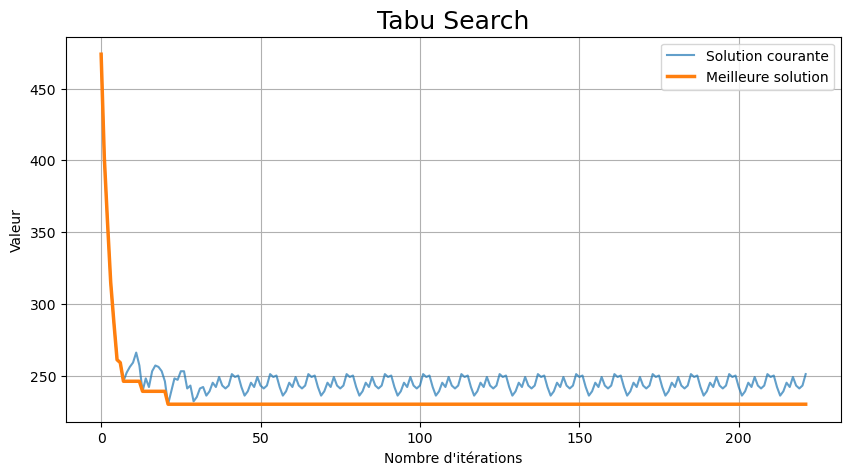

In [6]:
# Paramètres
iter_max = 200
taille_tabou = 10

val_depart = 1000000
while val_depart == 1000000:
    sol_initiale = generer_random_solution(n, nb_v)
    val_depart = distance_total(sol_initiale, mat, dems, cap)

sol_TS, courants_TS, meilleurs_courants_TS = recherche_tabou_traject(
    sol_initiale, mat, dems, cap, taille_tabou, iter_max
)

afficher_courbe(courants_TS, meilleurs_courants_TS, "Tabu Search")

In [7]:
def borne_inferieure(matrice, demandes, capacite_max):
    n = len(matrice)
    villes = range(n)

    prob = LpProblem("CVRP_Lower_Bound", LpMinimize)

    x = LpVariable.dicts('route', (villes, villes), 0, 1, LpBinary)

    prob += lpSum([matrice[i][j] * x[i][j] for i in villes for j in villes if i != j])
    
    # Contrainte 1 : Chaque ville (sauf dépôt) doit être visitée une fois
    for j in range(1, n):
        prob += lpSum([x[i][j] for i in villes if i != j]) == 1
        prob += lpSum([x[j][i] for i in villes if i != j]) == 1
        
    # Contrainte 2 : Le dépôt doit voir sortir/entrer autant de véhicules que nécessaire
    prob += lpSum([x[0][j] for j in range(1, n)]) >= 1
    prob += lpSum([x[i][0] for i in range(1, n)]) >= 1

    prob.solve(PULP_CBC_CMD(msg=0))
    
    return value(prob.objective) if (LpStatus[prob.status] == "Optimal") else None

borne = borne_inferieure(mat, dems, cap)
valeur_actuelle = distance_total(sol_TS, mat, dems, cap)

print(f"Borne inférieure théorique : {borne}")
print(f"Valeur de ta solution Tabou : {valeur_actuelle}")

if borne:
    gap = ((valeur_actuelle - borne) / borne) * 100
    print(f"L'écart (GAP) est de : {gap:.2f}%")

Borne inférieure théorique : 159.0
Valeur de ta solution Tabou : 230
L'écart (GAP) est de : 44.65%


IntProgress(value=0, layout=Layout(width='100%'), max=50)

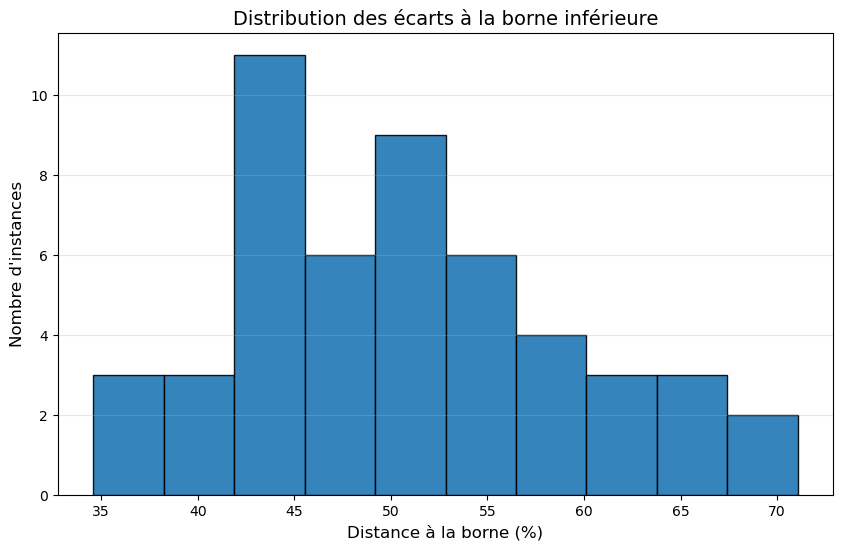

Moyenne du GAP sur 50 tests : 50.84%


In [8]:
gaps = deque(())
nb_tests = 50
iter_max = 100
taille_tabou = 10

bar = IntProgress(min=0, max=nb_tests, layout={"width" : "100%"})
display(bar)

for _ in range(nb_tests):
    borne = borne_inferieure(mat, dems, cap)

    val_depart = 1000000
    while val_depart == 1000000:
        solution_initiale = generer_random_solution(n, nb_v)
        val_depart = distance_total(solution_initiale, mat, dems, cap)

    sol_TS = recherche_tabou(solution_initiale, mat, dems, cap, taille_tabou, iter_max)
    val_finale = distance_total(sol_TS, mat, dems, cap)

    if borne and borne > 0:
        ecart = ((val_finale - borne) / borne) * 100
        gaps.append(ecart)
    
    bar.value += 1

bar.close()

if gaps:
    plt.figure(figsize=(10, 6))
    plt.hist(gaps, bins=10, edgecolor='black', alpha=0.9)
    
    plt.title("Distribution des écarts à la borne inférieure", fontsize=14)
    plt.xlabel("Distance à la borne (%)", fontsize=12)
    plt.ylabel("Nombre d'instances", fontsize=12)
    plt.grid(axis='y', alpha=0.3)
    plt.show();
    
    print(f"Moyenne du GAP sur {nb_tests} tests : {sum(gaps) / len(gaps):.2f}%")

IntProgress(value=0, layout=Layout(width='100%'), max=195)

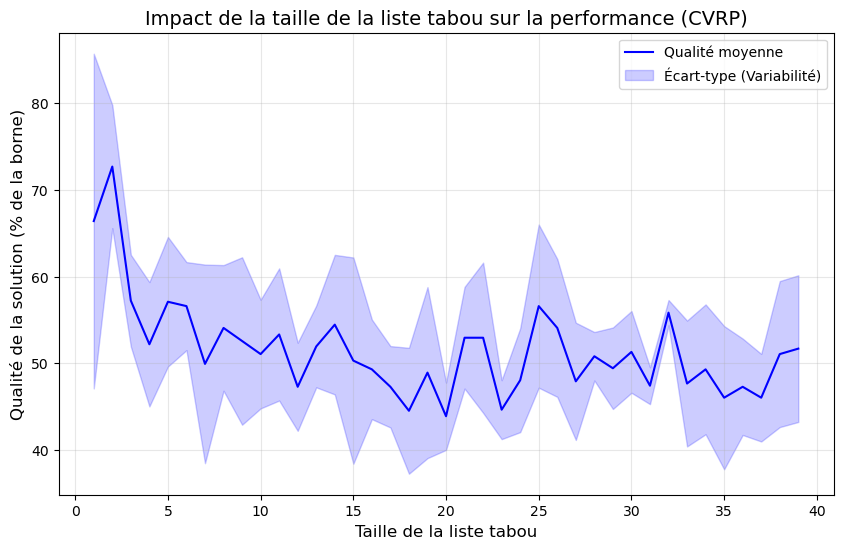

In [9]:
tabou_min = 1
tabou_max = 40
nb_test = 5    
iter_max = 50  

nb_steps_bar = (tabou_max - tabou_min) * nb_test
bar = IntProgress(min=0, max=nb_steps_bar, layout={"width" : "100%"})
display(bar)

moyennes = []
deviations = []

for taille_tabou in range(tabou_min, tabou_max):
    resultats_taille = []

    for _ in range(nb_test):
        borne = borne_inferieure(mat, dems, cap)

        val_depart = 1000000
        while val_depart == 1000000:
            sol_init = generer_random_solution(n, nb_v)
            val_depart = distance_total(sol_init, mat, dems, cap)

        sol = recherche_tabou(sol_init, mat, dems, cap, taille_tabou, iter_max)
        
        val_sol = distance_total(sol, mat, dems, cap)
        score = ((val_sol - borne) / borne) * 100
        resultats_taille.append(score)
        
        bar.value += 1
        
    moyennes.append(statistics.mean(resultats_taille))
    deviations.append(np.std(resultats_taille))

bar.close()

plt.figure(figsize=(10, 6))

plt.plot(range(tabou_min, tabou_max), moyennes, label="Qualité moyenne", color="blue")

plt.fill_between(range(tabou_min, tabou_max), 
                 np.subtract(moyennes, deviations), 
                 np.add(moyennes, deviations), 
                 alpha=0.2, color="blue", label="Écart-type (Variabilité)")

plt.xlabel("Taille de la liste tabou", fontsize=12)
plt.ylabel("Qualité de la solution (% de la borne)", fontsize=12)
plt.title("Impact de la taille de la liste tabou sur la performance (CVRP)", fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show();

IntProgress(value=0, layout=Layout(width='100%'))

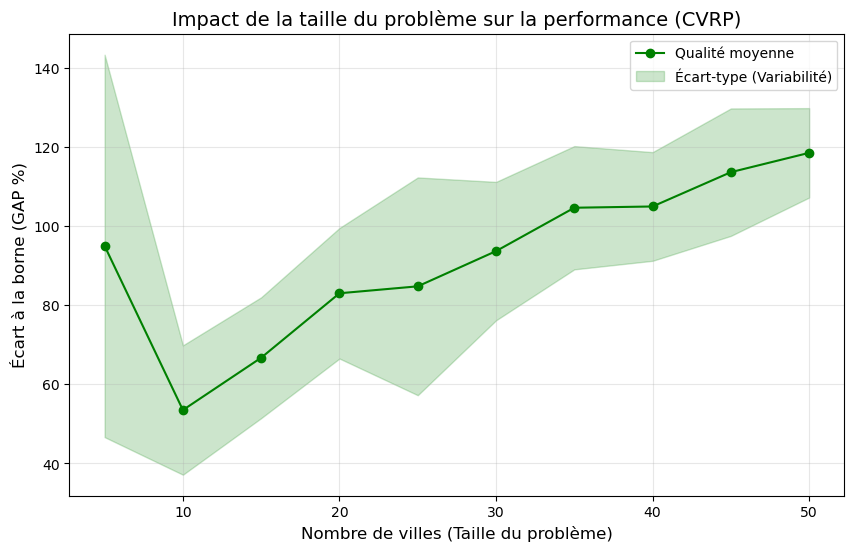

In [10]:
def generer_auto(n_villes, n_vehicules):
    taille = n_villes + 1
    matrice = [[0] * taille for _ in range(taille)]
    for i in range(taille):
        for j in range(i + 1, taille):
            dist = random.randint(5, 50)
            matrice[i][j] = matrice[j][i] = dist
    demandes = [0] + [random.randint(1, 10) for _ in range(n_villes)]
    capacite_max = int((sum(demandes) / n_vehicules) * 1.2)
    return n_villes, n_vehicules, matrice, demandes, capacite_max

villes_min   = 5
villes_max   = 55
villes_steps = 5
nb_test      = 10
taille_tabou = 15
iter_max     = 100

nb_steps_bar = ((villes_max - villes_min) / villes_steps) * nb_test
bar = IntProgress(min=0, max=nb_steps_bar, layout={"width" : "100%"})
display(bar)

moyennes   = []
deviations = []

for n_villes in range(villes_min, villes_max, villes_steps):
    resultats_n = []
    
    for _ in range(nb_test):
        nb_v_t = max(2, n_villes // 5)
        n_t, nb_v_t, mat_t, dems_t, cap_t = generer_auto(n_villes, nb_v_t)
        
        borne = borne_inferieure(mat_t, dems_t, cap_t)

        val_depart = 1000000
        while val_depart == 1000000:
            sol_init = generer_random_solution(n_t, nb_v_t)
            val_depart = distance_total(sol_init, mat_t, dems_t, cap_t)

        sol = recherche_tabou(sol_init, mat_t, dems_t, cap_t, taille_tabou, iter_max)
        val_sol = distance_total(sol, mat_t, dems_t, cap_t)

        if borne and borne > 0:
            score = ((val_sol - borne) / borne) * 100
            resultats_n.append(score)
        
        bar.value += 1
        
    moyennes.append(statistics.mean(resultats_n))
    deviations.append(np.std(resultats_n))

bar.close()

plt.figure(figsize=(10, 6))

plt.plot(range(villes_min, villes_max, villes_steps), moyennes, label="Qualité moyenne", color="green", marker='o')

plt.fill_between(range(villes_min, villes_max, villes_steps),
                 np.subtract(moyennes, deviations),
                 np.add(moyennes, deviations),
                 alpha=0.2, color="green", label="Écart-type (Variabilité)")

plt.xlabel("Nombre de villes (Taille du problème)", fontsize=12)
plt.ylabel("Écart à la borne (GAP %)", fontsize=12)
plt.title("Impact de la taille du problème sur la performance (CVRP)", fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show();